In [1]:
from google.colab import files

uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [2]:
import pandas as pd

data = pd.read_csv("Churn_Modelling.csv")

print("Dataset shape:", data.shape)
print(data.head())

Dataset shape: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826

In [3]:
print(data['Exited'].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [4]:
print(data['Exited'].value_counts(normalize=True) * 100)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [5]:
data = data.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print(data.head())
print(data.shape)

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  
(10000, 11)


In [6]:
data = pd.get_dummies(
    data,
    columns=['Geography', 'Gender'],
    drop_first=True
)

print(data.head())
print(data.columns)

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1              False   
1               1        112542.58       0              False   
2               0        113931.57       1              False   
3               0         93826.63       0              False   
4               1         79084.10       0              False   

   Geography_Spain  Gender_Male  
0            False        False  
1             True        False  
2            False        False  
3            False        False  
4             True        Fals

In [7]:
X = data.drop(columns=['Exited'])
y = data['Exited']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 11)
Target: (10000,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 11)
Testing data: (2000, 11)


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [10]:
log_pred = log_model.predict(X_test_scaled)

print(log_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [11]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    log_pred,
    target_names=["Stayed", "Churned"]
))

Logistic Regression Accuracy: 80.8 %

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [13]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:20])

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0]


In [14]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:",
      round(rf_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Stayed", "Churned"]
))

Random Forest Accuracy: 86.05 %

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



In [15]:
log_accuracy = accuracy_score(y_test, log_pred)

print("MODEL COMPARISON")
print("-----------------------------")
print("Logistic Regression:",
      round(log_accuracy * 100, 2), "%")

print("Random Forest:",
      round(rf_accuracy * 100, 2), "%")

MODEL COMPARISON
-----------------------------
Logistic Regression: 80.8 %
Random Forest: 86.05 %


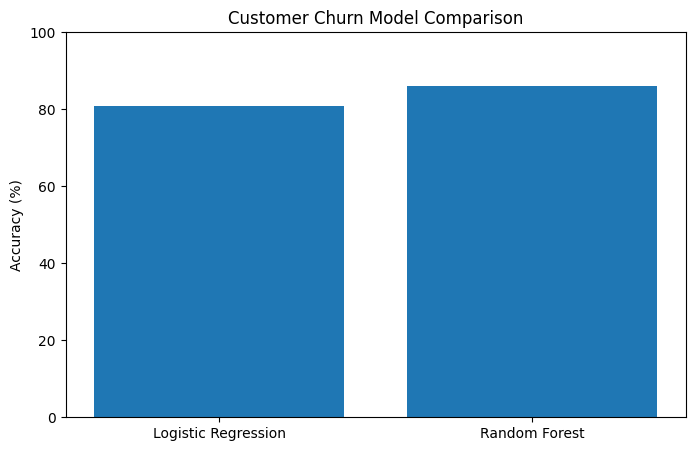

In [17]:
import matplotlib.pyplot as plt
models = ["Logistic Regression", "Random Forest"]
accuracies = [log_accuracy * 100, rf_accuracy * 100]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")
plt.title("Customer Churn Model Comparison")
plt.ylim(0, 100)

plt.show()

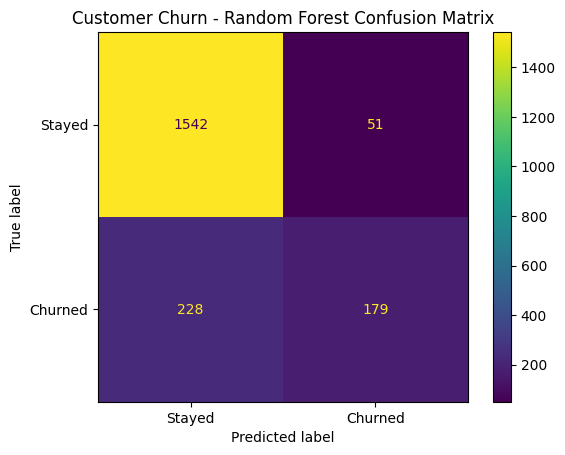

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Customer Churn - Random Forest Confusion Matrix")
plt.show()

In [19]:
new_customer = pd.DataFrame([{
    'CreditScore': 650,
    'Age': 45,
    'Tenure': 3,
    'Balance': 80000,
    'NumOfProducts': 1,
    'HasCrCard': 1,
    'IsActiveMember': 0,
    'EstimatedSalary': 60000,
    'Geography_Germany': True,
    'Geography_Spain': False,
    'Gender_Male': False
}])

new_customer = new_customer[X.columns]

prediction = rf_model.predict(new_customer)

if prediction[0] == 1:
    print("⚠️ Customer is likely to CHURN")
else:
    print("✅ Customer is likely to STAY")

⚠️ Customer is likely to CHURN


In [20]:
probability = rf_model.predict_proba(new_customer)[0][1]

print("Probability of Churn:",
      round(probability * 100, 2), "%")

Probability of Churn: 55.0 %


In [21]:
import joblib

joblib.dump(rf_model, "customer_churn_model.pkl")
joblib.dump(scaler, "customer_churn_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [22]:
from google.colab import files

files.download("customer_churn_model.pkl")
files.download("customer_churn_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>